# PCA dan Clustering
kita gunakan dataset https://www.kaggle.com/datasets/mehmettahiraslan/customer-shopping-dataset untuk latihan PCA dan clustering

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

In [2]:
# import data

df_sales = pd.read_csv("dataset/customer_shopping_data.csv")
df_sales.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [3]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


tidak ada missing value - skip step missing value handling

kolom yang sifatnya data unik boleh kita drop

In [4]:
df_sales = df_sales.drop(columns=['customer_id', 'invoice_no'])

ubah tipe data:
- invoice_date ke datetime
- sisanya sudah sesuai


In [5]:
df_sales['invoice_date'] = pd.to_datetime(df_sales['invoice_date'], format='%d/%m/%Y')

In [6]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   gender          99457 non-null  object        
 1   age             99457 non-null  int64         
 2   category        99457 non-null  object        
 3   quantity        99457 non-null  int64         
 4   price           99457 non-null  float64       
 5   payment_method  99457 non-null  object        
 6   invoice_date    99457 non-null  datetime64[ns]
 7   shopping_mall   99457 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 6.1+ MB


terakhir untuk data categorical kita encode

In [7]:
df_sales.columns

Index(['gender', 'age', 'category', 'quantity', 'price', 'payment_method',
       'invoice_date', 'shopping_mall'],
      dtype='object')

In [8]:
df_sales2 = df_sales.copy()

In [9]:
cols_toencode = ['gender', 'category', 'payment_method', 'shopping_mall']

for col in cols_toencode:
    # display(df_sales[col].value_counts())
    # print(df_sales[col].nunique())

    # label encoding
    le = LabelEncoder()
    df_sales2[col] = le.fit_transform(df_sales2[col])
    print(f"Label Encoding {col}: {le.classes_}")

df_sales2.head()


Label Encoding gender: ['Female' 'Male']
Label Encoding category: ['Books' 'Clothing' 'Cosmetics' 'Food & Beverage' 'Shoes' 'Souvenir'
 'Technology' 'Toys']
Label Encoding payment_method: ['Cash' 'Credit Card' 'Debit Card']
Label Encoding shopping_mall: ['Cevahir AVM' 'Emaar Square Mall' 'Forum Istanbul' 'Istinye Park'
 'Kanyon' 'Mall of Istanbul' 'Metrocity' 'Metropol AVM' 'Viaport Outlet'
 'Zorlu Center']


,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,0,28,1,5,1500.40,1,2022-08-05,4
1,1,21,4,3,1800.51,2,2021-12-12,2
2,1,20,1,1,300.08,0,2021-11-09,6
3,0,66,4,5,3000.85,1,2021-05-16,7
4,0,53,0,4,60.60,0,2021-10-24,4


note: untuk yang jumlah kategori nya banyak, boleh menggunakan one hot encoder

In [11]:
# pisahin fitur2 yang mau digunakan untuk clustering
# exclude invoice_date
X = df_sales2.drop(columns=['invoice_date'])
X.head()

,gender,age,category,quantity,price,payment_method,shopping_mall
0,0,28,1,5,1500.40,1,4
1,1,21,4,3,1800.51,2,2
2,1,20,1,1,300.08,0,6
3,0,66,4,5,3000.85,1,7
4,0,53,0,4,60.60,0,4


In [ ]:
# scaler
scaler = StandardScaler()
df_sales_scaled = scaler.fit_transform(X)

In [15]:
# PCA
model_pca = PCA(random_state=42)
X_pca = model_pca.fit_transform(df_sales_scaled)

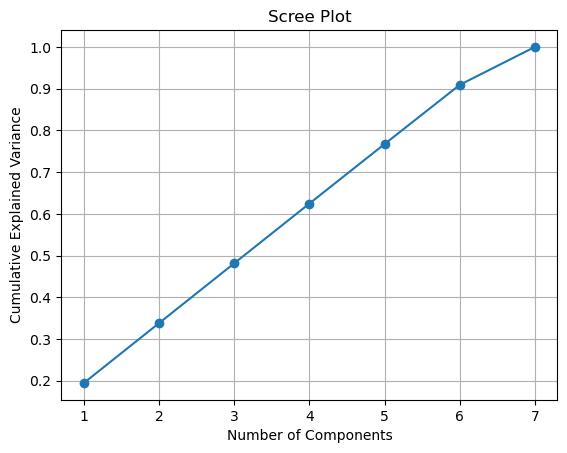

In [18]:
# pemilihan jumlah komponen PCA
# scree plot menggunakan explained variance
explained_variance = model_pca.explained_variance_ratio_
explained_variance_cumsum = np.cumsum(explained_variance)

plt.figure()
plt.plot(explained_variance_cumsum, marker='o')

plt.title('Scree Plot')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.xticks(ticks=np.arange(len(explained_variance_cumsum)), labels=np.arange(1, len(explained_variance_cumsum)+1))
plt.grid()
plt.show()

dari 7 fitur awal, setelah PCA, kalau kita ambil minimal 70% variance explained, kita perlu 5 components.

In [20]:
# kita ambil 5 komponen (70% variance explained)
model_pca_5 = PCA(n_components=5, random_state=42)
X_pca_5 = model_pca_5.fit_transform(df_sales_scaled)

In [21]:
X_pca_5.shape

(99457, 5)

In [23]:
# clustering dengan DBSCAN
# DBSCAN tidak perlu menentukan jumlah cluster di awal

model_dbscan = DBSCAN(eps=1, min_samples=5)

# buat kolom cluster
df_sales2['cluster'] = model_dbscan.fit_predict(X_pca_5)

In [24]:
df_sales2.head()

,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,cluster
0,0,28,1,5,1500.40,1,2022-08-05,4,0
1,1,21,4,3,1800.51,2,2021-12-12,2,0
2,1,20,1,1,300.08,0,2021-11-09,6,0
3,0,66,4,5,3000.85,1,2021-05-16,7,0
4,0,53,0,4,60.60,0,2021-10-24,4,0


In [25]:
df_sales2['cluster'].value_counts()

cluster
0     97455
4       289
2       262
9       216
3       212
8       188
1       163
7       137
11      136
6       121
10      108
5        93
12       77
Name: count, dtype: int64

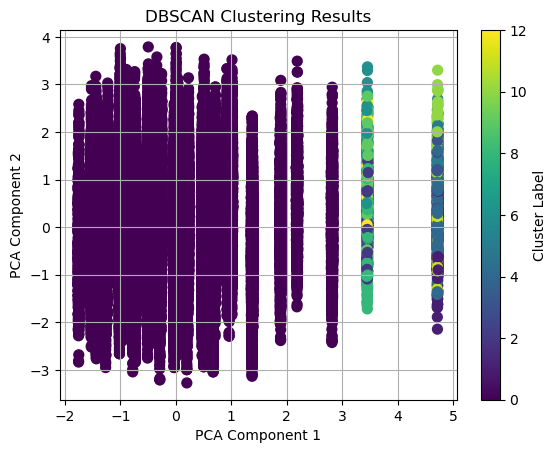

In [26]:
# optional - visualisasi hasil clustering
plt.figure()
plt.scatter(X_pca_5[:, 0], X_pca_5[:, 1], c=df_sales2['cluster'], cmap='viridis', s=50)
plt.title('DBSCAN Clustering Results')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster Label')
plt.grid()
plt.show()